C:\Users\李晨语\AppData\Local\Temp\ipykernel_1560\3146072510.py:12: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')
C:\Users\李晨语\AppData\Local\Temp\ipykernel_1560\3146072510.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')


country
United States                    241822
Germany                          153186
United Kingdom                    62761
China                             56298
France                            49764
Netherlands                       46793
Czechia                           46765
Japan                             45622
Canada                            32343
Italy                             26431
Australia                         26296
Switzerland                       25914
New Zealand                       17078
Poland                            13911
Austria                           10375
Bulgaria                           7357
Sweden                             7320
Finland                            7131
Spain                              6184
Denmark                            5744
India                              5689
Hungary                            5629
United Arab Emirates               5264
Hong Kong                          4767
Malaysia                        

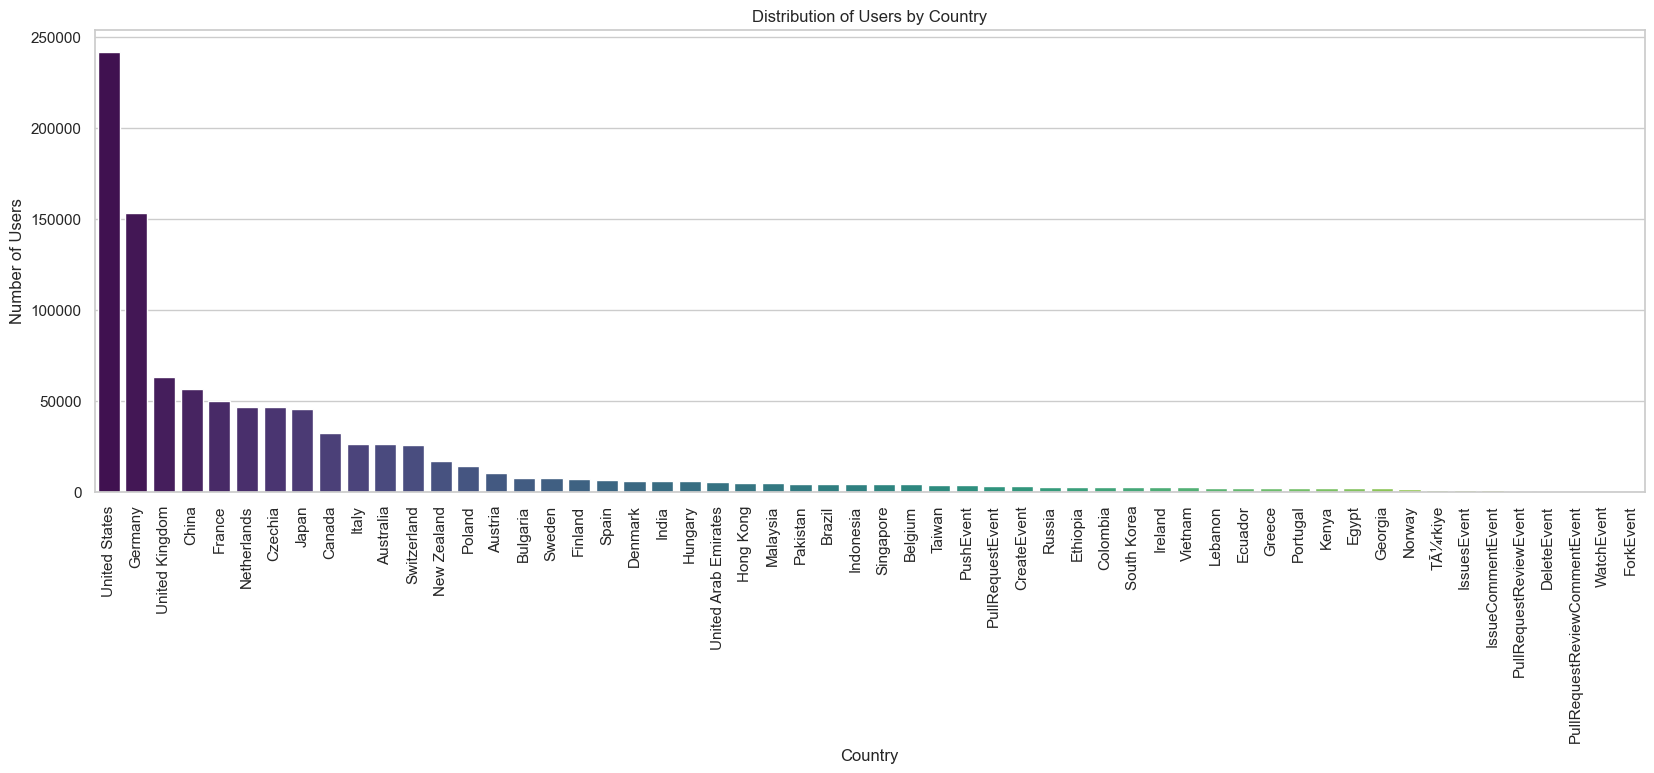

location
Germany                               99478
Prague                                36400
Japan                                 26986
Switzerland                           15555
Houston, TX                           15449
                                      ...  
Miami, Florida                          861
Southern California                     822
Lisbon, Portugal                        784
Everything everywhere all at once.      635
Phoenixville, PA                         75
Name: count, Length: 264, dtype: int64
hour
0.0     29659
1.0     30321
2.0     28607
3.0     25839
4.0     23466
5.0     23892
6.0     31742
7.0     51366
8.0     44674
9.0     50416
10.0    51253
11.0    50069
12.0    49753
13.0    54292
14.0    57297
15.0    57282
16.0    55988
17.0    50182
18.0    49844
19.0    50664
20.0    46565
21.0    44044
22.0    42941
23.0    36841
Name: count, dtype: int64


In [3]:
#1.人口统计分析
#国家和地区分布：统计用户所在国家和地区的分布，识别主要的开发者集中地。
#城市级别分布：分析主要城市的开发者密度，发现技术热点区域。
#时区分布:了解用户的时区分布，分析不同地区用户的协作时间模式。

import pandas as pd

# 加载数据
try:
    df = pd.read_csv('users_combined_info_500.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')

# 查看前几行数据和基本信息
#print(df.head())
#print(df.info())

# 检查是否有缺失值
#print(df.isnull().sum())

# 统计国家分布
country_counts = df['country'].value_counts()

# 输出国家分布
print(country_counts)

import matplotlib.pyplot as plt
import seaborn as sns

# 设置画图风格
sns.set(style="whitegrid")

# 绘制国家分布的条形图
plt.figure(figsize=(20, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribution of Users by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.show()


# 统计城市的分布
city_counts = df['location'].value_counts()

# 输出城市分布
print(city_counts)

# 确保event_time字段是时间格式
df['event_time'] = pd.to_datetime(df['event_time'])

# 提取时区（假设data中没有明确的时区信息，可以从event_time推断）
df['hour'] = df['event_time'].dt.hour

# 统计时区（小时）的分布
timezone_distribution = df['hour'].value_counts().sort_index()

# 显示结果
print(timezone_distribution)


In [5]:
#2.协作行为分析
#提交频率：统计每个用户的提交次数，识别高活跃用户和低活跃用户。

import pandas as pd
try:
    df = pd.read_csv('users_combined_info_500.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')


# 按用户统计提交频率
user_submission_frequency = df.groupby('user_id').size()

# 识别高活跃用户和低活跃用户
high_active_users = user_submission_frequency[user_submission_frequency > user_submission_frequency.quantile(0.75)]
low_active_users = user_submission_frequency[user_submission_frequency < user_submission_frequency.quantile(0.25)]

# 显示结果
print('高活跃用户:', high_active_users)
print('低活跃用户:', low_active_users)

高活跃用户: user_id
225          2885
13564        3140
26967        3214
27350        4509
32321        3284
             ... 
51138685     3291
66076021     3735
88161975     3394
91018726     4098
100913391    3177
Length: 93, dtype: int64
低活跃用户: user_id
1945        1526
2621         796
44640       1483
47792       1337
70381       1601
            ... 
57876960     861
62513924    1068
62625502     621
83238715     923
89584709     862
Length: 93, dtype: int64


C:\Users\李晨语\AppData\Local\Temp\ipykernel_1560\3942408987.py:12: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')


C:\Users\李晨语\AppData\Local\Temp\ipykernel_21116\1629151210.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')


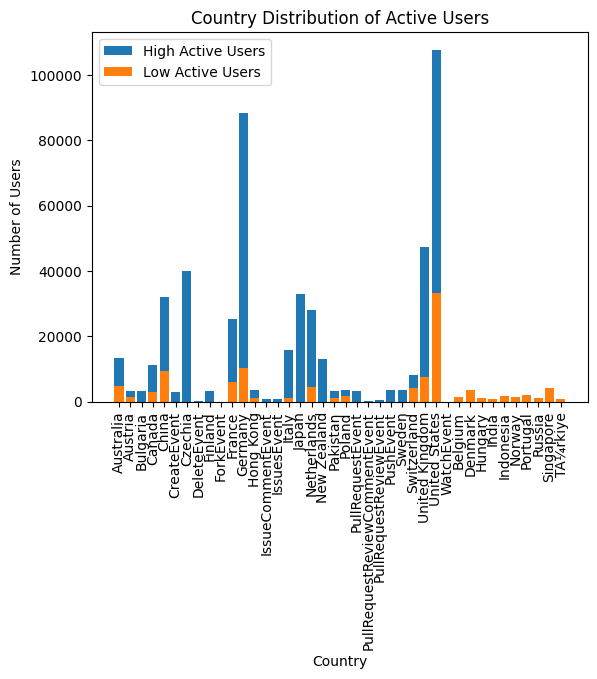

In [5]:
#3.不同国家高、低活跃用户的分布
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('users_combined_info_500.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')

# 按用户统计提交频率
user_submission_frequency = df.groupby('user_id').size()
high_active_users = user_submission_frequency[user_submission_frequency > user_submission_frequency.quantile(0.75)]
low_active_users = user_submission_frequency[user_submission_frequency < user_submission_frequency.quantile(0.25)]

# 按国家统计高活跃用户数量
high_active_country_count = df[df['user_id'].isin(high_active_users.index)].groupby('country').size()
# 按国家统计低活跃用户数量
low_active_country_count = df[df['user_id'].isin(low_active_users.index)].groupby('country').size()

plt.bar(high_active_country_count.index, high_active_country_count.values, label='High Active Users')
plt.bar(low_active_country_count.index, low_active_country_count.values, label='Low Active Users')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.title('Country Distribution of Active Users')
plt.xticks(rotation=90)
plt.legend()
plt.show()

C:\Users\李晨语\AppData\Local\Temp\ipykernel_21116\2718478287.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')


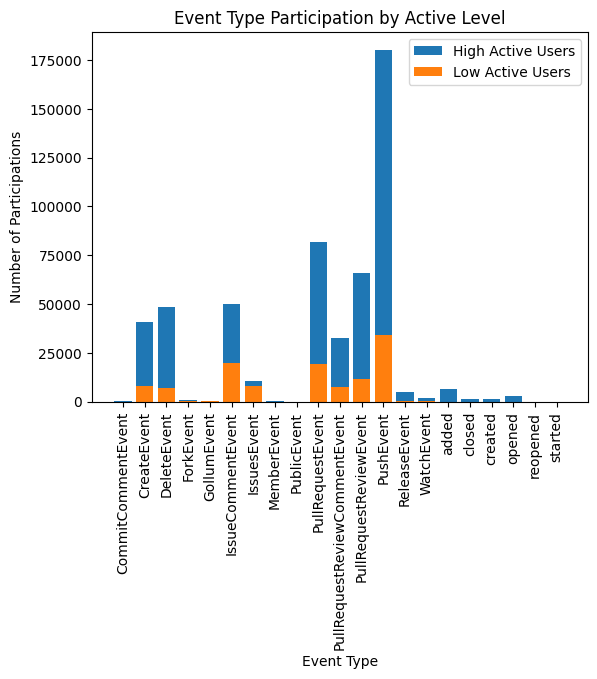

In [ ]:
#4.不同事件类型下高、低活跃用户的参与度
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('users_combined_info_500.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('users_combined_info_500.csv', encoding='ISO-8859-1')
    
# 按事件类型统计高活跃用户参与次数
high_active_event_type_count = df[df['user_id'].isin(high_active_users.index)].groupby('event_type').size()
# 按事件类型统计低活跃用户参与次数
low_active_event_type_count = df[df['user_id'].isin(low_active_users.index)].groupby('event_type').size()

plt.bar(high_active_event_type_count.index, high_active_event_type_count.values, label='High Active Users')
plt.bar(low_active_event_type_count.index, low_active_event_type_count.values, label='Low Active Users')
plt.xlabel('Event Type')
plt.ylabel('Number of Participations')
plt.title('Event Type Participation by Active Level')
plt.xticks(rotation=90)
plt.legend()
plt.show()